## **CryptoCast: Multi-Horizon Bitcoin Price Forecasting Using Deep Learning**


DATA LOADING

In [1]:
import pandas as pd
df=pd.read_csv("/content/Bitcoin Historical Data (1).csv")
display(df)

,Date,Price,Open,High,Low,Vol.,Change %
0,24-03-2024,"67,211.9","64,036.5","67,587.8","63,812.9",65.59K,4.96%
1,23-03-2024,"64,037.8","63,785.6","65,972.4","63,074.9",35.11K,0.40%
2,22-03-2024,"63,785.5","65,501.5","66,633.3","62,328.3",72.43K,-2.62%
3,21-03-2024,"65,503.8","67,860.0","68,161.7","64,616.1",75.26K,-3.46%
4,20-03-2024,"67,854.0","62,046.8","68,029.5","60,850.9",133.53K,9.35%
...,...,...,...,...,...,...,...
4994,22-07-2010,0.1,0.1,0.1,0.1,2.16K,0.00%
4995,21-07-2010,0.1,0.1,0.1,0.1,0.58K,0.00%
4996,20-07-2010,0.1,0.1,0.1,0.1,0.26K,0.00%
4997,19-07-2010,0.1,0.1,0.1,0.1,0.57K,0.00%


DATA PREPROCESSING AND DATA CLEANING

1.Convert Date Column into Datetime Format

In [4]:
df["Date"] = pd.to_datetime(df["Date"])
display(df)

,Date,Price,Open,High,Low,Vol.,Change %
4998,2010-07-18,0.1,0.0,0.1,0.1,0.08K,0.00%
4997,2010-07-19,0.1,0.1,0.1,0.1,0.57K,0.00%
4996,2010-07-20,0.1,0.1,0.1,0.1,0.26K,0.00%
4995,2010-07-21,0.1,0.1,0.1,0.1,0.58K,0.00%
4994,2010-07-22,0.1,0.1,0.1,0.1,2.16K,0.00%
...,...,...,...,...,...,...,...
4,2024-03-20,"67,854.0","62,046.8","68,029.5","60,850.9",133.53K,9.35%
3,2024-03-21,"65,503.8","67,860.0","68,161.7","64,616.1",75.26K,-3.46%
2,2024-03-22,"63,785.5","65,501.5","66,633.3","62,328.3",72.43K,-2.62%
1,2024-03-23,"64,037.8","63,785.6","65,972.4","63,074.9",35.11K,0.40%


2.Sort Dataset by Date

In [5]:
df = df.sort_values("Date")
display(df)

,Date,Price,Open,High,Low,Vol.,Change %
4998,2010-07-18,0.1,0.0,0.1,0.1,0.08K,0.00%
4997,2010-07-19,0.1,0.1,0.1,0.1,0.57K,0.00%
4996,2010-07-20,0.1,0.1,0.1,0.1,0.26K,0.00%
4995,2010-07-21,0.1,0.1,0.1,0.1,0.58K,0.00%
4994,2010-07-22,0.1,0.1,0.1,0.1,2.16K,0.00%
...,...,...,...,...,...,...,...
4,2024-03-20,"67,854.0","62,046.8","68,029.5","60,850.9",133.53K,9.35%
3,2024-03-21,"65,503.8","67,860.0","68,161.7","64,616.1",75.26K,-3.46%
2,2024-03-22,"63,785.5","65,501.5","66,633.3","62,328.3",72.43K,-2.62%
1,2024-03-23,"64,037.8","63,785.6","65,972.4","63,074.9",35.11K,0.40%


3.Fill Missing Values

In [6]:
df.isnull().sum()

,0
Date,0
Price,0
Open,0
High,0
Low,0
Vol.,6
Change %,0


In [7]:
df = df.fillna(method="ffill")
display(df)

/tmp/ipykernel_1156/1952700265.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


,Date,Price,Open,High,Low,Vol.,Change %
4998,2010-07-18,0.1,0.0,0.1,0.1,0.08K,0.00%
4997,2010-07-19,0.1,0.1,0.1,0.1,0.57K,0.00%
4996,2010-07-20,0.1,0.1,0.1,0.1,0.26K,0.00%
4995,2010-07-21,0.1,0.1,0.1,0.1,0.58K,0.00%
4994,2010-07-22,0.1,0.1,0.1,0.1,2.16K,0.00%
...,...,...,...,...,...,...,...
4,2024-03-20,"67,854.0","62,046.8","68,029.5","60,850.9",133.53K,9.35%
3,2024-03-21,"65,503.8","67,860.0","68,161.7","64,616.1",75.26K,-3.46%
2,2024-03-22,"63,785.5","65,501.5","66,633.3","62,328.3",72.43K,-2.62%
1,2024-03-23,"64,037.8","63,785.6","65,972.4","63,074.9",35.11K,0.40%


4.Remove % Symbol and Convert to Float

In [8]:
df['Change %'] = df['Change %'].str.replace('%', '').astype(float)
display(df)

,Date,Price,Open,High,Low,Vol.,Change %
4998,2010-07-18,0.1,0.0,0.1,0.1,0.08K,0.00
4997,2010-07-19,0.1,0.1,0.1,0.1,0.57K,0.00
4996,2010-07-20,0.1,0.1,0.1,0.1,0.26K,0.00
4995,2010-07-21,0.1,0.1,0.1,0.1,0.58K,0.00
4994,2010-07-22,0.1,0.1,0.1,0.1,2.16K,0.00
...,...,...,...,...,...,...,...
4,2024-03-20,"67,854.0","62,046.8","68,029.5","60,850.9",133.53K,9.35
3,2024-03-21,"65,503.8","67,860.0","68,161.7","64,616.1",75.26K,-3.46
2,2024-03-22,"63,785.5","65,501.5","66,633.3","62,328.3",72.43K,-2.62
1,2024-03-23,"64,037.8","63,785.6","65,972.4","63,074.9",35.11K,0.40


5.Converting Columns into Float

In [11]:
df['Price'] = df['Price'].astype(float)
df['Open'] = df['Open'].str.replace(',', '').astype(float)
df['High'] = df['High'].str.replace(',', '').astype(float)
df['Low'] = df['Low'].str.replace(',', '').astype(float)
display(df)

,Date,Price,Open,High,Low,Vol.,Change %
4998,2010-07-18,0.1,0.0,0.1,0.1,0.08K,0.00
4997,2010-07-19,0.1,0.1,0.1,0.1,0.57K,0.00
4996,2010-07-20,0.1,0.1,0.1,0.1,0.26K,0.00
4995,2010-07-21,0.1,0.1,0.1,0.1,0.58K,0.00
4994,2010-07-22,0.1,0.1,0.1,0.1,2.16K,0.00
...,...,...,...,...,...,...,...
4,2024-03-20,67854.0,62046.8,68029.5,60850.9,133.53K,9.35
3,2024-03-21,65503.8,67860.0,68161.7,64616.1,75.26K,-3.46
2,2024-03-22,63785.5,65501.5,66633.3,62328.3,72.43K,-2.62
1,2024-03-23,64037.8,63785.6,65972.4,63074.9,35.11K,0.40


In [12]:
df.dtypes

,0
Date,datetime64[ns]
Price,float64
Open,float64
High,float64
Low,float64
Vol.,object
Change %,float64


6. Create Volume Conversion Function

In [14]:
def convert_volume(x):
    if 'K' in str(x):
        return float(x.replace('K', '')) * 1e3
    elif 'M' in str(x):
        return float(x.replace('M', '')) * 1e6
    elif 'B' in str(x):
        return float(x.replace('B', '')) * 1e9
    return float(x)

df['Vol.'] = df['Vol.'].apply(convert_volume)
display(df)

,Date,Price,Open,High,Low,Vol.,Change %
4998,2010-07-18,0.1,0.0,0.1,0.1,80.0,0.00
4997,2010-07-19,0.1,0.1,0.1,0.1,570.0,0.00
4996,2010-07-20,0.1,0.1,0.1,0.1,260.0,0.00
4995,2010-07-21,0.1,0.1,0.1,0.1,580.0,0.00
4994,2010-07-22,0.1,0.1,0.1,0.1,2160.0,0.00
...,...,...,...,...,...,...,...
4,2024-03-20,67854.0,62046.8,68029.5,60850.9,133530.0,9.35
3,2024-03-21,65503.8,67860.0,68161.7,64616.1,75260.0,-3.46
2,2024-03-22,63785.5,65501.5,66633.3,62328.3,72430.0,-2.62
1,2024-03-23,64037.8,63785.6,65972.4,63074.9,35110.0,0.40


In [15]:
df.dtypes

,0
Date,datetime64[ns]
Price,float64
Open,float64
High,float64
Low,float64
Vol.,float64
Change %,float64


FEATURE SCALING

In [16]:
features = ['Price','Open', 'High', 'Low', 'Vol.', 'Change %']
target_col = 'Price'
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import joblib

#min-max scalar
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(df[features])
y_scaled = target_scaler.fit_transform(df[[target_col]])

# Save scalers
joblib.dump(feature_scaler, "feature_scaler.pkl")
joblib.dump(target_scaler, "target_scaler.pkl")

print("Scalers saved successfully")

Scalers saved successfully


SEQUENCE CREATION

In [17]:
def create_sequences(X, y, seq_len=60, horizon=1):
    X_seq, y_seq = [], []

    for i in range(seq_len, len(X) - horizon + 1):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i + horizon - 1])

    return np.array(X_seq), np.array(y_seq)

SEQ_LEN = 60

X_1d, y_1d = create_sequences(X_scaled, y_scaled, SEQ_LEN, horizon=1)
X_3d, y_3d = create_sequences(X_scaled, y_scaled, SEQ_LEN, horizon=3)
X_7d, y_7d = create_sequences(X_scaled, y_scaled, SEQ_LEN, horizon=7)

print(X_1d.shape, y_1d.shape)
print(X_3d.shape, y_3d.shape)
print(X_7d.shape, y_7d.shape)

(4939, 60, 6) (4939, 1)
(4937, 60, 6) (4937, 1)
(4933, 60, 6) (4933, 1)


SPLITTING TRAIN-TEST DATA

In [18]:
split = int(len(X_1d) * 0.8)

X_train_1d, X_test_1d = X_1d[:split], X_1d[split:]
y_train_1d, y_test_1d = y_1d[:split], y_1d[split:]

X_train_3d, X_test_3d = X_3d[:split], X_3d[split:]
y_train_3d, y_test_3d = y_3d[:split], y_3d[split:]

X_train_7d, X_test_7d = X_7d[:split], X_7d[split:]
y_train_7d, y_test_7d = y_7d[:split], y_7d[split:]

LSTM MODEL

In [19]:
#LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ================= LSTM MODEL =================
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),

        LSTM(64),
        Dropout(0.2),

        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

In [20]:
model_1d = build_lstm_model((X_train_1d.shape[1], X_train_1d.shape[2]))
model_3d = build_lstm_model((X_train_3d.shape[1], X_train_3d.shape[2]))
model_7d = build_lstm_model((X_train_7d.shape[1], X_train_7d.shape[2]))

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_1d = model_1d.fit(
    X_train_1d,
    y_train_1d,
    validation_data=(X_test_1d, y_test_1d),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

history_3d = model_3d.fit(
    X_train_3d, y_train_3d,
    validation_data=(X_test_3d, y_test_3d),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

history_7d = model_7d.fit(
    X_train_7d, y_train_7d,
    validation_data=(X_test_7d, y_test_7d),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

model_1d.save("lstm_1day.h5")
model_3d.save("lstm_3day.h5")
model_7d.save("lstm_7day.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0013 - mae: 0.0161 - val_loss: 0.0025 - val_mae: 0.0424
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.2502e-04 - mae: 0.0116 - val_loss: 0.0033 - val_mae: 0.0407
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.6576e-04 - mae: 0.0113 - val_loss: 0.0016 - val_mae: 0.0274
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.7600e-04 - mae: 0.0098 - val_loss: 0.0014 - val_mae: 0.0305
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 3.9319e-04 - mae: 0.0096 - val_loss: 0.0064 - val_mae: 0.0684
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.6688e-04 - mae: 0.0102 - val_loss: 0.0017 - val_mae: 0.0271
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.6715e-04 - mae: 0.0092 - val_loss: 0.0010 - val_mae: 0.0210
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.4804e-04 - mae: 0.0088 - val_loss: 0.0012 - val_mae: 0.0287
Epoch 9/50
124/124 ━

In [21]:
import pickle
pickle.dump(history_1d.history, open("history_1d.pkl", "wb"))
pickle.dump(history_3d.history, open("history_3d.pkl", "wb"))
pickle.dump(history_7d.history, open("history_7d.pkl", "wb"))

In [22]:
pred_1d = model_1d.predict(X_test_1d)

pred_actual = target_scaler.inverse_transform(pred_1d)
y_actual = target_scaler.inverse_transform(y_test_1d)

print(pred_actual[:5])
print(y_actual[:5])

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[[34138.906]
 [34319.31 ]
 [34305.14 ]
 [34013.652]
 [33657.95 ]]
[[34227.7]
 [33113. ]
 [32728.1]
 [32820.7]
 [31840.5]]


In [23]:
import numpy as np

def evaluate_forecast(model, X_test, y_test, scaler, horizon_name="1-Day"):
    # Predict
    pred = model.predict(X_test)

    # Inverse scaling
    pred_actual = scaler.inverse_transform(pred)
    y_actual = scaler.inverse_transform(y_test)

    # Metrics
    mae = mean_absolute_error(y_actual, pred_actual)
    rmse = np.sqrt(mean_squared_error(y_actual, pred_actual))
    mape = np.mean(np.abs((y_actual - pred_actual) / y_actual)) * 100
    r2 = r2_score(y_actual, pred_actual)

    print(f"\n📌 {horizon_name} Metrics")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAPE : {mape:.2f}%")
    print(f"R²   : {r2:.4f}")

    return y_actual, pred_actual, mae, rmse, mape, r2

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# 1-Day
y1, p1, mae1, rmse1, mape1, r21 = evaluate_forecast(
    model_1d, X_test_1d, y_test_1d, target_scaler, "1-Day"
)

# 3-Day
y3, p3, mae3, rmse3, mape3, r23 = evaluate_forecast(
    model_3d, X_test_3d, y_test_3d, target_scaler, "3-Day"
)

# 7-Day
y7, p7, mae7, rmse7, mape7, r27 = evaluate_forecast(
    model_7d, X_test_7d, y_test_7d, target_scaler, "7-Day"
)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

📌 1-Day Metrics
MAE  : 1301.76
RMSE : 1888.38
MAPE : 3.69%
R²   : 0.9788
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

📌 3-Day Metrics
MAE  : 2768.51
RMSE : 3602.20
MAPE : 8.54%
R²   : 0.9232
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

📌 7-Day Metrics
MAE  : 3223.94
RMSE : 4257.60
MAPE : 9.90%
R²   : 0.8931


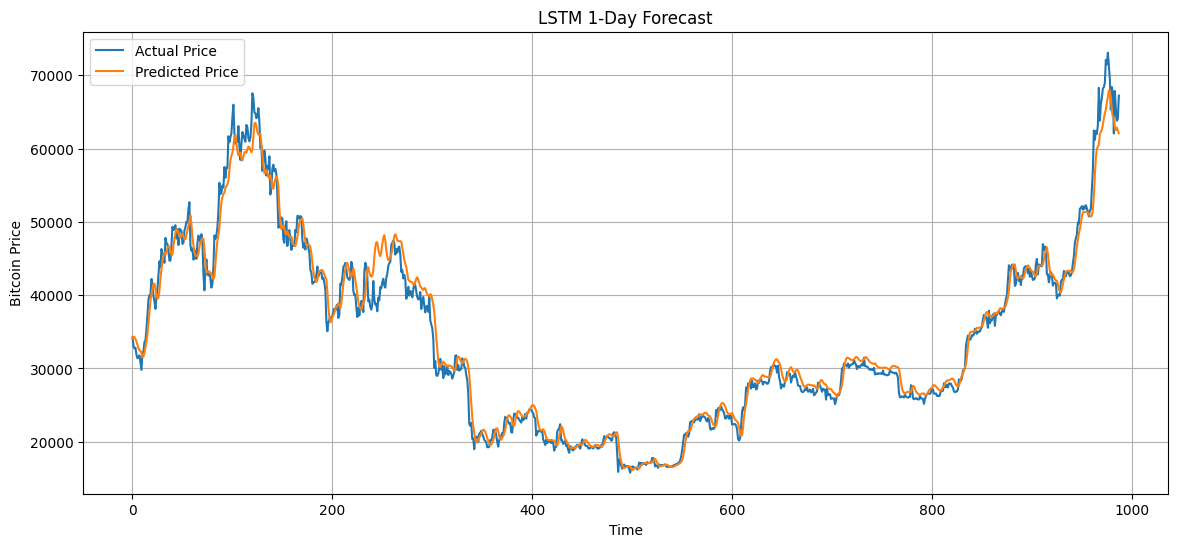

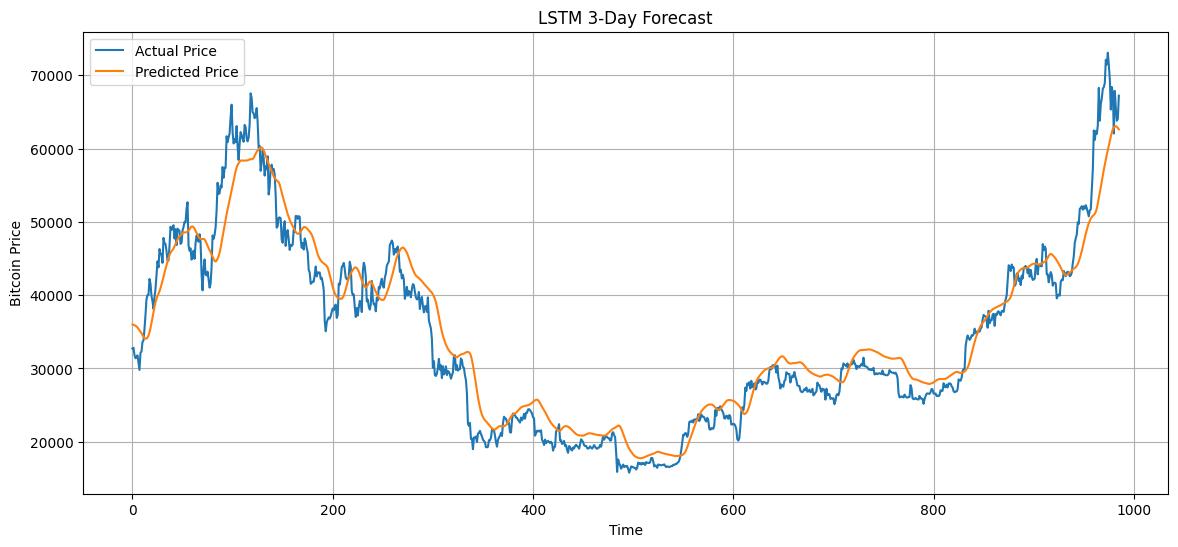

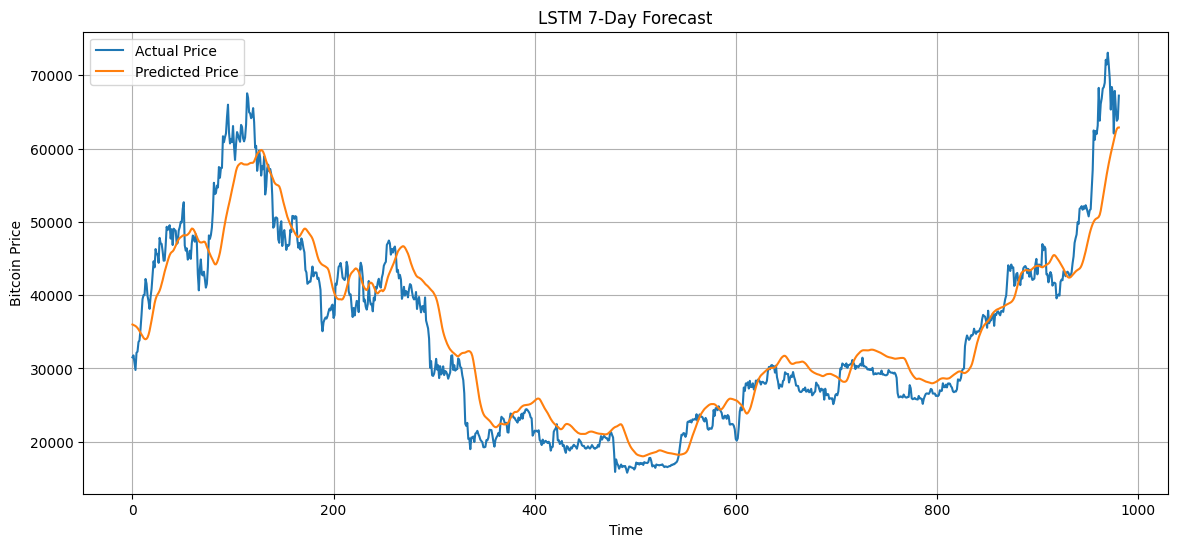

In [25]:
#Actual vs predicted plot
import matplotlib.pyplot as plt

def plot_forecast(actual, predicted, title):
    plt.figure(figsize=(14, 6))
    plt.plot(actual, label="Actual Price")
    plt.plot(predicted, label="Predicted Price")
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Bitcoin Price")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_forecast(y1, p1, "LSTM 1-Day Forecast")
plot_forecast(y3, p3, "LSTM 3-Day Forecast")
plot_forecast(y7, p7, "LSTM 7-Day Forecast")

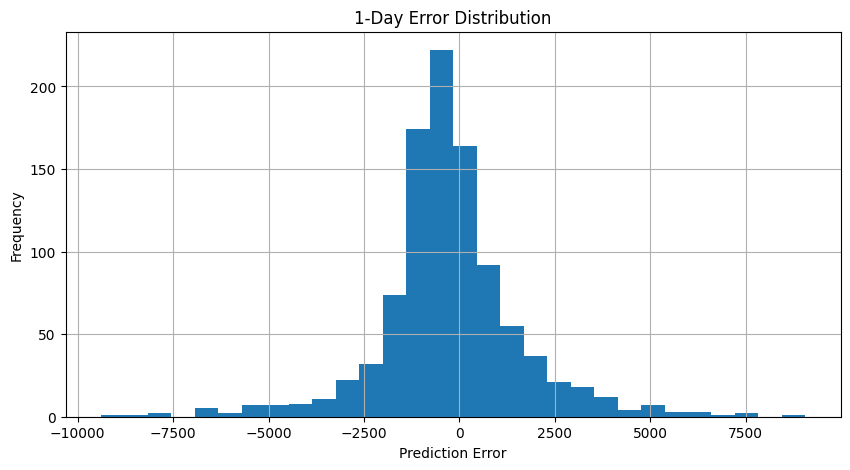

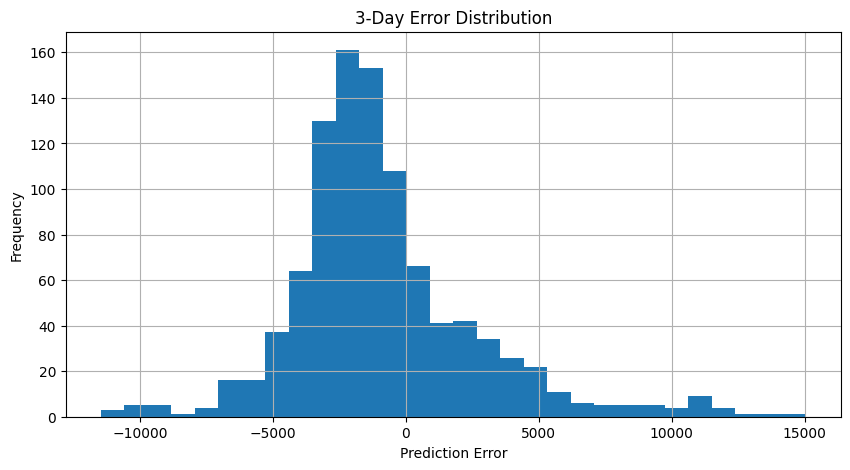

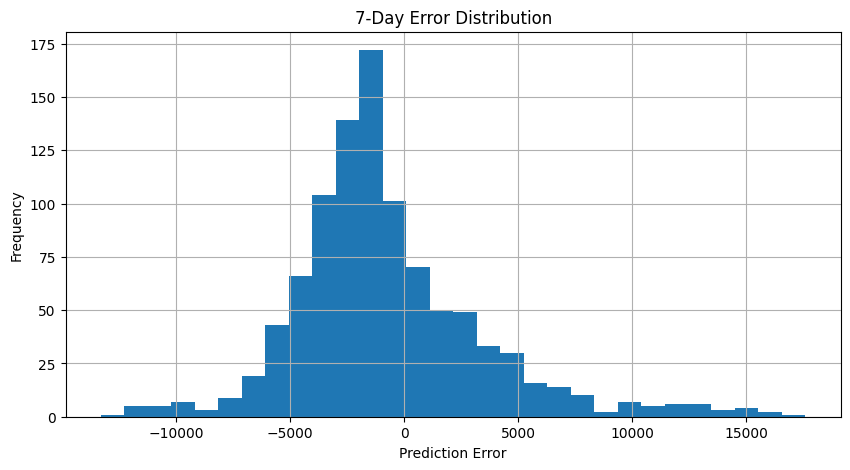

In [26]:
def plot_error_distribution(actual, predicted, title):
    errors = actual.flatten() - predicted.flatten()

    plt.figure(figsize=(10, 5))
    plt.hist(errors, bins=30)
    plt.title(title)
    plt.xlabel("Prediction Error")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

plot_error_distribution(y1, p1, "1-Day Error Distribution")
plot_error_distribution(y3, p3, "3-Day Error Distribution")
plot_error_distribution(y7, p7, "7-Day Error Distribution")

In [27]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Horizon": ["1-Day", "3-Day", "7-Day"],
    "MAE": [mae1, mae3, mae7],
    "RMSE": [rmse1, rmse3, rmse7],
    "MAPE": [mape1, mape3, mape7],
    "R2": [r21, r23, r27]
})

print(comparison_df)

  Horizon          MAE         RMSE      MAPE        R2
0   1-Day  1301.764133  1888.383117  3.692121  0.978838
1   3-Day  2768.511485  3602.196380  8.536067  0.923152
2   7-Day  3223.940755  4257.600988  9.900100  0.893067


In [28]:
comparison_df.to_csv("lstm_metrics.csv", index=False)
print("Metrics saved successfully")

Metrics saved successfully


CNN MODEL

In [29]:
#CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

def build_cnn_model(input_shape):
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation="relu",
               input_shape=input_shape),
        MaxPooling1D(pool_size=2),

        Conv1D(filters=128, kernel_size=3, activation="relu"),
        MaxPooling1D(pool_size=2),

        Flatten(),

        Dense(64, activation="relu"),
        Dropout(0.2),

        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

In [30]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# 1-Day
cnn_1d = build_cnn_model((X_train_1d.shape[1], X_train_1d.shape[2]))
Historycnn1d=cnn_1d.fit(
    X_train_1d, y_train_1d,
    validation_data=(X_test_1d, y_test_1d),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

# 3-Day
cnn_3d = build_cnn_model((X_train_3d.shape[1], X_train_3d.shape[2]))
Historycnn3d=cnn_3d.fit(
    X_train_3d, y_train_3d,
    validation_data=(X_test_3d, y_test_3d),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

# 7-Day
cnn_7d = build_cnn_model((X_train_7d.shape[1], X_train_7d.shape[2]))
Historycnn7d=cnn_7d.fit(
    X_train_7d, y_train_7d,
    validation_data=(X_test_7d, y_test_7d),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

cnn_1d.save("cnn_1day.h5")
cnn_3d.save("cnn_3day.h5")
cnn_7d.save("cnn_7day.h5")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


124/124 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - loss: 0.0022 - mae: 0.0220 - val_loss: 0.0053 - val_mae: 0.0510
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0012 - mae: 0.0152 - val_loss: 0.0060 - val_mae: 0.0565
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.3603e-04 - mae: 0.0114 - val_loss: 0.0059 - val_mae: 0.0562
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.0423e-04 - mae: 0.0128 - val_loss: 0.0046 - val_mae: 0.0468
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9009e-04 - mae: 0.0113 - val_loss: 0.0046 - val_mae: 0.0463
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.8974e-04 - mae: 0.0122 - val_loss: 0.0075 - val_mae: 0.0611
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.1077e-04 - mae: 0.0109 - val_loss: 0.0060 - val_mae: 0.0528
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.7317e-04 - mae: 0.0110 - val_loss: 0.0080 - val_mae: 0.0623
Epoch 9/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_forecast(model, X_test, y_test, scaler, name):
    pred = model.predict(X_test)

    pred_actual = scaler.inverse_transform(pred)
    y_actual = scaler.inverse_transform(y_test)

    mae = mean_absolute_error(y_actual, pred_actual)
    rmse = np.sqrt(mean_squared_error(y_actual, pred_actual))
    mape = np.mean(np.abs((y_actual - pred_actual) / y_actual)) * 100
    r2 = r2_score(y_actual, pred_actual)

    print(f"\n{name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R2: {r2:.4f}")

    return y_actual, pred_actual, mae, rmse, mape, r2

In [32]:
y1, p1, mae1, rmse1, mape1, r21 = evaluate_forecast(
    cnn_1d, X_test_1d, y_test_1d, target_scaler, "CNN 1-Day"
)

y3, p3, mae3, rmse3, mape3, r23 = evaluate_forecast(
    cnn_3d, X_test_3d, y_test_3d, target_scaler, "CNN 3-Day"
)

y7, p7, mae7, rmse7, mape7, r27 = evaluate_forecast(
    cnn_7d, X_test_7d, y_test_7d, target_scaler, "CNN 7-Day"
)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step

CNN 1-Day
MAE: 3264.49
RMSE: 4260.48
MAPE: 10.38%
R2: 0.8923
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step

CNN 3-Day
MAE: 3332.13
RMSE: 4534.91
MAPE: 9.75%
R2: 0.8782
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step

CNN 7-Day
MAE: 3575.25
RMSE: 5090.20
MAPE: 9.91%
R2: 0.8472


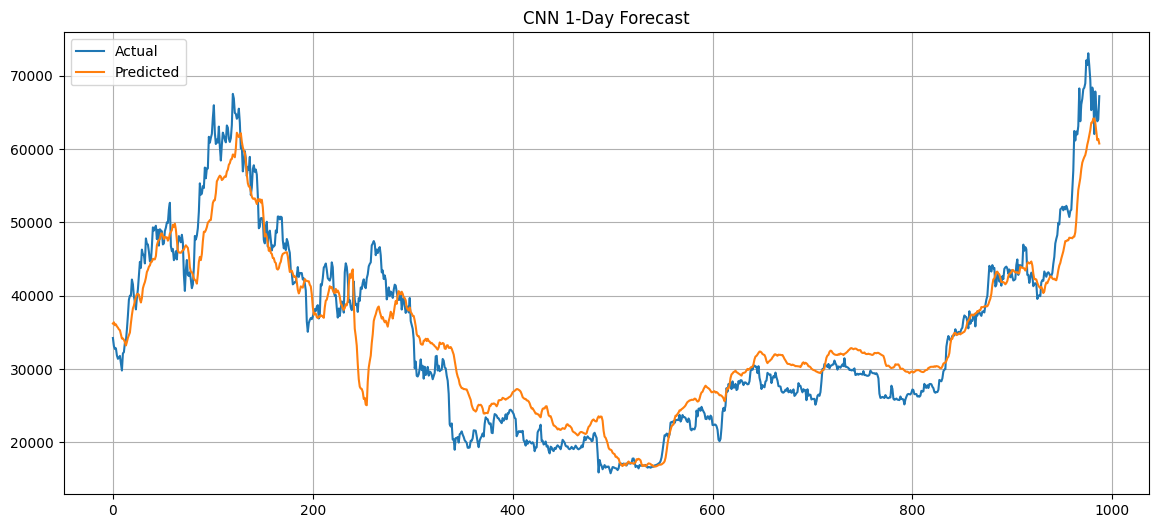

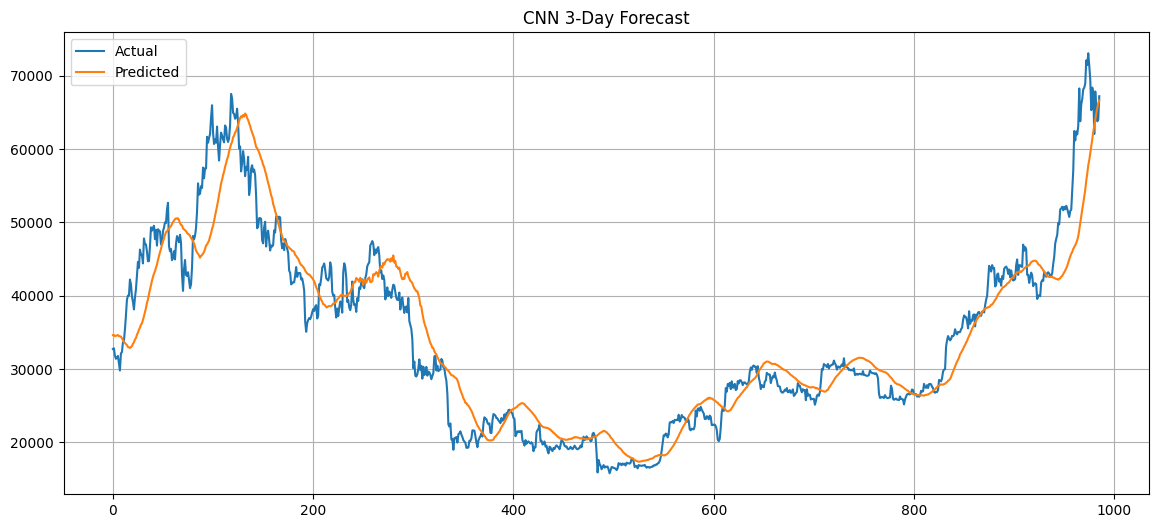

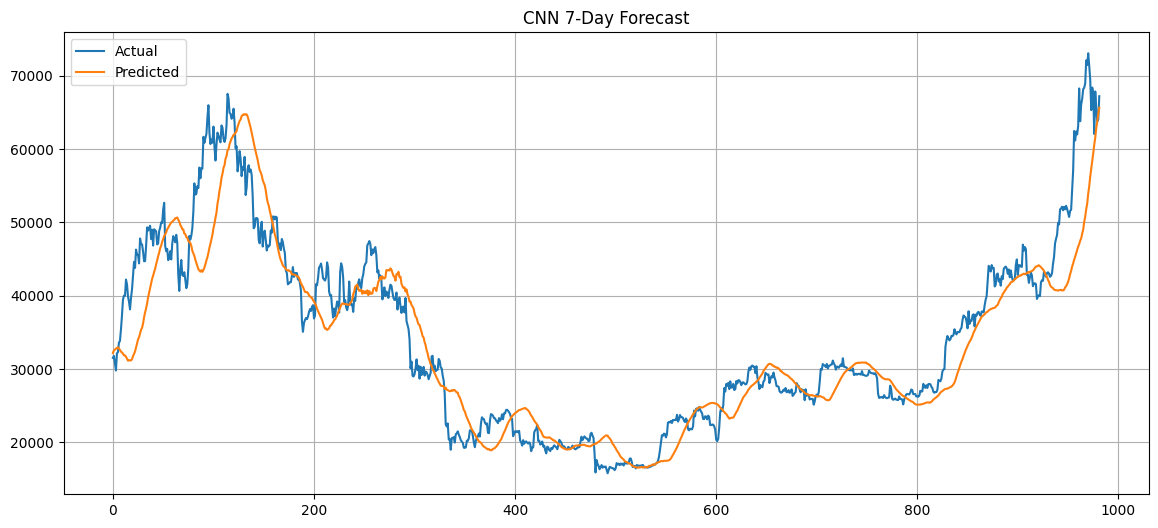

In [33]:
# forecast plot
# import matplotlib.pyplot as plt

def plot_forecast(actual, predicted, title):
    plt.figure(figsize=(14, 6))
    plt.plot(actual, label="Actual")
    plt.plot(predicted, label="Predicted")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_forecast(y1, p1, "CNN 1-Day Forecast")
plot_forecast(y3, p3, "CNN 3-Day Forecast")
plot_forecast(y7, p7, "CNN 7-Day Forecast")

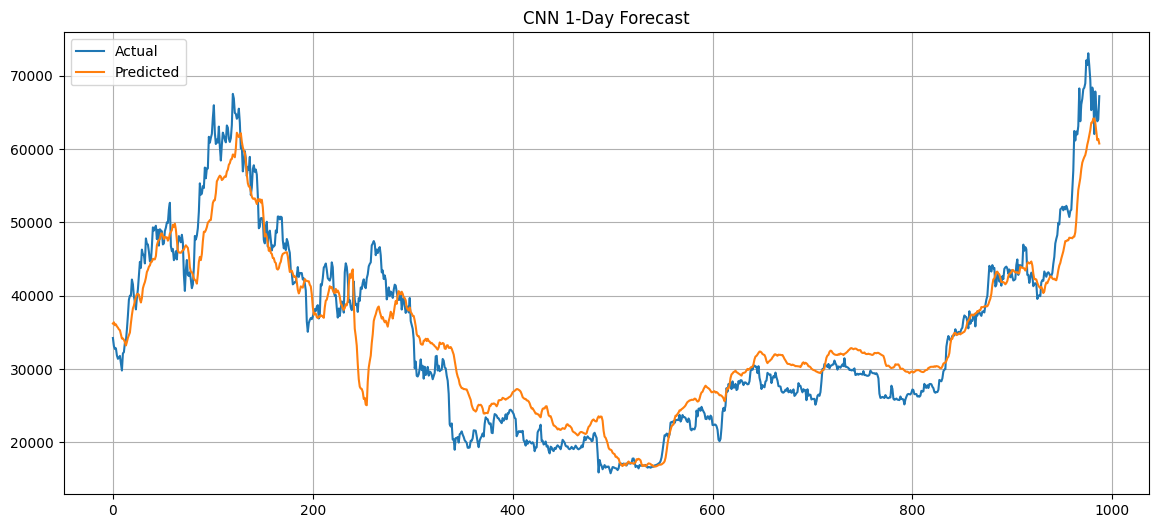

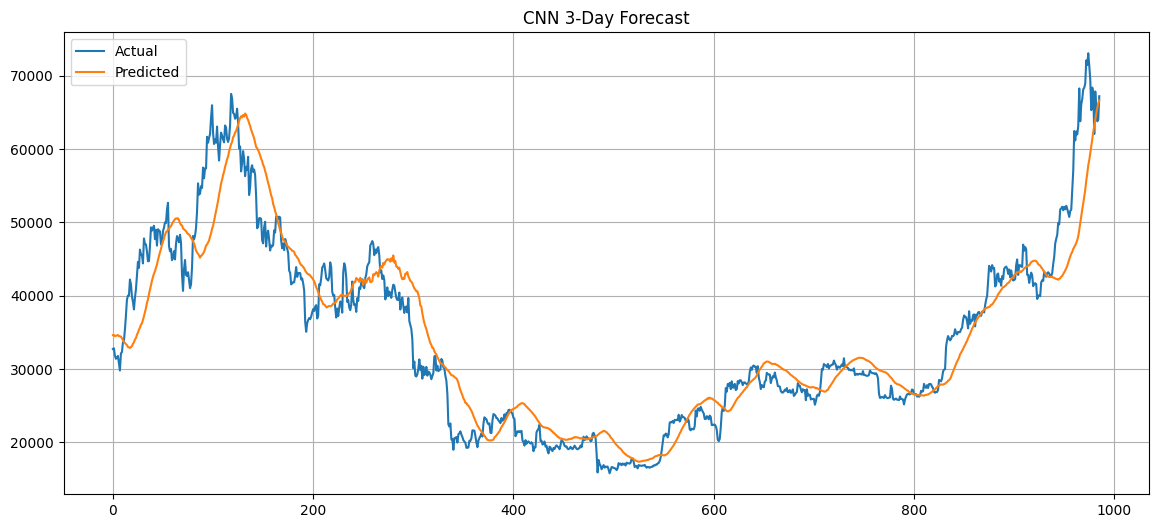

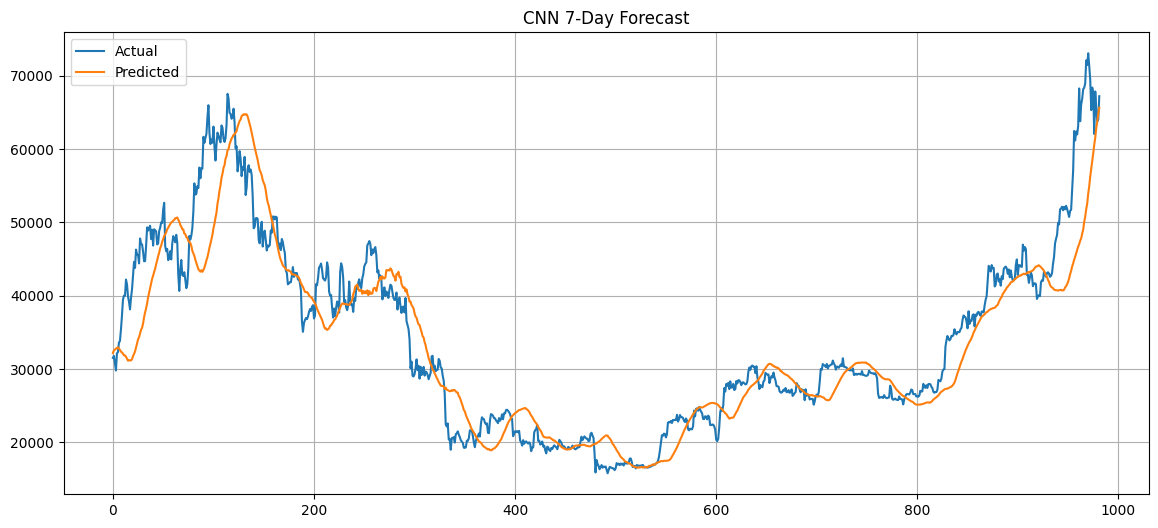

In [34]:
#Error distribution plot
import matplotlib.pyplot as plt

def plot_forecast(actual, predicted, title):
    plt.figure(figsize=(14, 6))
    plt.plot(actual, label="Actual")
    plt.plot(predicted, label="Predicted")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_forecast(y1, p1, "CNN 1-Day Forecast")
plot_forecast(y3, p3, "CNN 3-Day Forecast")
plot_forecast(y7, p7, "CNN 7-Day Forecast")

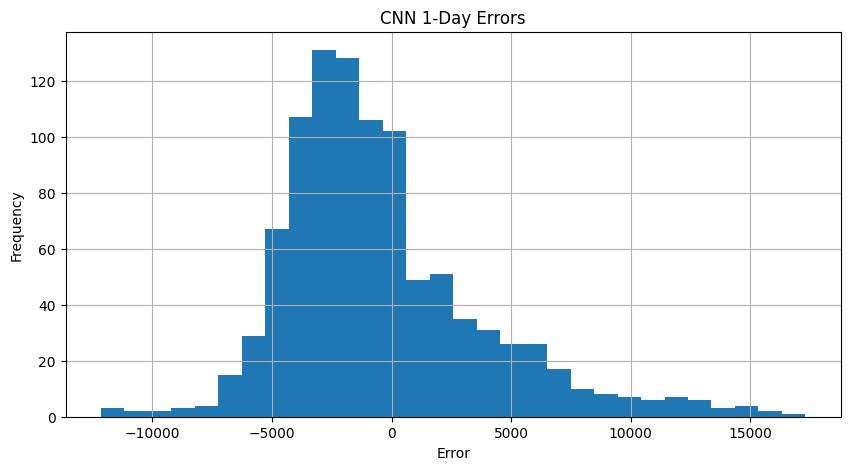

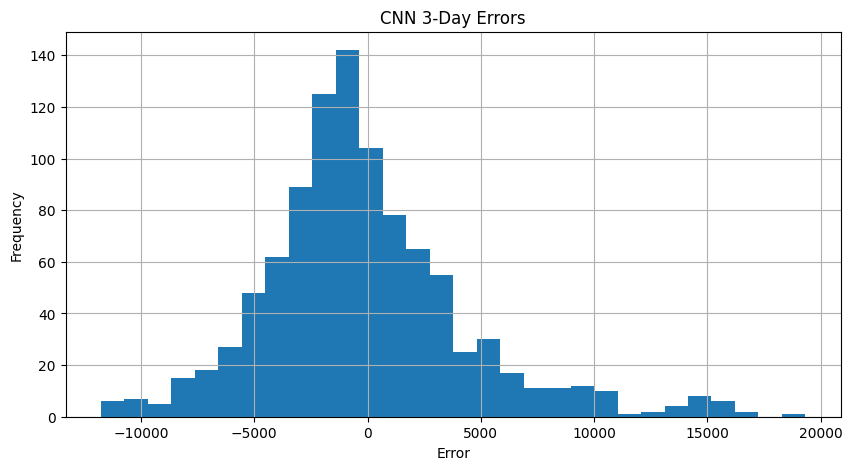

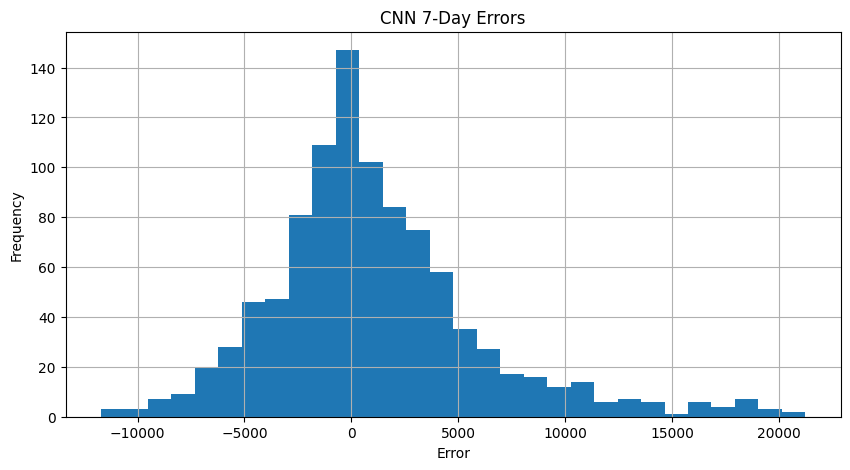

In [35]:
def plot_error_distribution(actual, predicted, title):
    errors = actual.flatten() - predicted.flatten()

    plt.figure(figsize=(10, 5))
    plt.hist(errors, bins=30)
    plt.title(title)
    plt.xlabel("Error")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

plot_error_distribution(y1, p1, "CNN 1-Day Errors")
plot_error_distribution(y3, p3, "CNN 3-Day Errors")
plot_error_distribution(y7, p7, "CNN 7-Day Errors")

In [36]:
import pickle
pickle.dump(history_1d.history, open("history_1d.pkl", "wb"))
pickle.dump(history_3d.history, open("history_3d.pkl", "wb"))
pickle.dump(history_7d.history, open("history_7d.pkl", "wb"))

RNN MODEL

In [37]:
#RNN code
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def build_rnn_model(input_shape):
    model = Sequential([
        SimpleRNN(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),

        SimpleRNN(64),
        Dropout(0.2),

        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def build_rnn_model(input_shape):
    model = Sequential([
        SimpleRNN(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),

        SimpleRNN(64),
        Dropout(0.2),

        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model

In [38]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

rnn_1d = build_rnn_model((X_train_1d.shape[1], X_train_1d.shape[2]))
rnn_3d = build_rnn_model((X_train_3d.shape[1], X_train_3d.shape[2]))
rnn_7d = build_rnn_model((X_train_7d.shape[1], X_train_7d.shape[2]))

rnn_1d.fit(
    X_train_1d, y_train_1d,
    validation_data=(X_test_1d, y_test_1d),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

rnn_3d.fit(
    X_train_3d, y_train_3d,
    validation_data=(X_test_3d, y_test_3d),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

rnn_7d.fit(
    X_train_7d, y_train_7d,
    validation_data=(X_test_7d, y_test_7d),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

rnn_1d.save("rnn_1day.h5")
rnn_3d.save("rnn_3day.h5")
rnn_7d.save("rnn_7day.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.0096 - mae: 0.0575 - val_loss: 0.0015 - val_mae: 0.0296
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0021 - mae: 0.0272 - val_loss: 0.0045 - val_mae: 0.0483
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0014 - mae: 0.0225 - val_loss: 0.0025 - val_mae: 0.0413
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0013 - mae: 0.0193 - val_loss: 0.0037 - val_mae: 0.0490
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.3204e-04 - mae: 0.0161 - val_loss: 0.0032 - val_mae: 0.0492
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.5430e-04 - mae: 0.0143 - val_loss: 0.0016 - val_mae: 0.0297
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.2694e-04 - mae: 0.0133 - val_loss: 0.0010 - val_mae: 0.0221
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.8887e-04 - mae: 0.0124 - val_loss: 0.0016 - val_mae: 0.0303
Epoch 9/50
124/124 ━━━━━━━━━━━━

In [39]:
y1_rnn, p1_rnn, mae1_rnn, rmse1_rnn, mape1_rnn, r21_rnn = evaluate_forecast(
    rnn_1d, X_test_1d, y_test_1d, target_scaler, "RNN 1-Day"
)

y3_rnn, p3_rnn, mae3_rnn, rmse3_rnn, mape3_rnn, r23_rnn = evaluate_forecast(
    rnn_3d, X_test_3d, y_test_3d, target_scaler, "RNN 3-Day"
)

y7_rnn, p7_rnn, mae7_rnn, rmse7_rnn, mape7_rnn, r27_rnn = evaluate_forecast(
    rnn_7d, X_test_7d, y_test_7d, target_scaler, "RNN 7-Day"
)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step

RNN 1-Day
MAE: 1366.78
RMSE: 1882.26
MAPE: 4.01%
R2: 0.9790
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step

RNN 3-Day
MAE: 3241.18
RMSE: 4526.94
MAPE: 8.94%
R2: 0.8786
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step

RNN 7-Day
MAE: 3854.53
RMSE: 5084.91
MAPE: 12.50%
R2: 0.8475


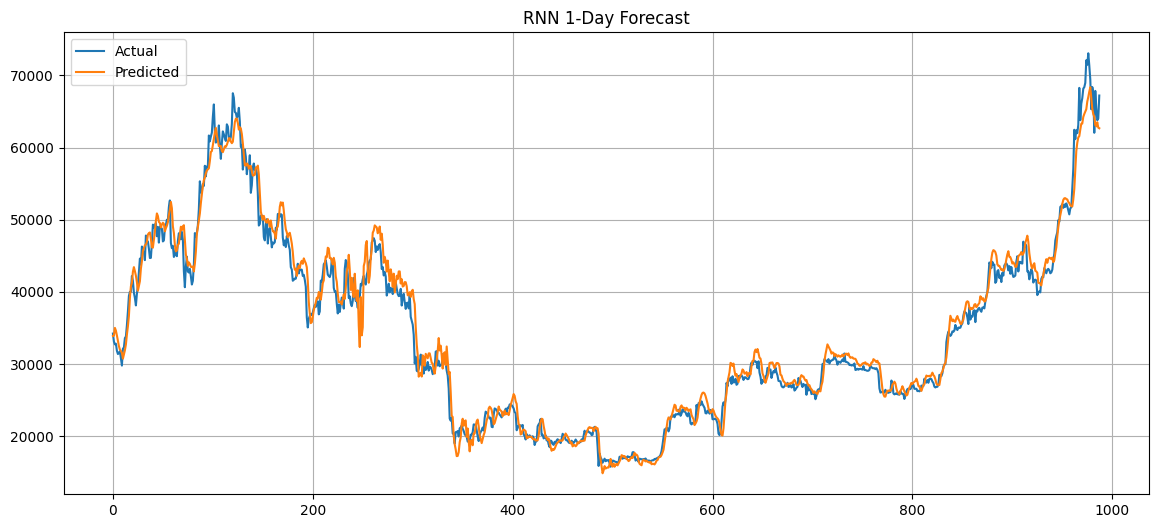

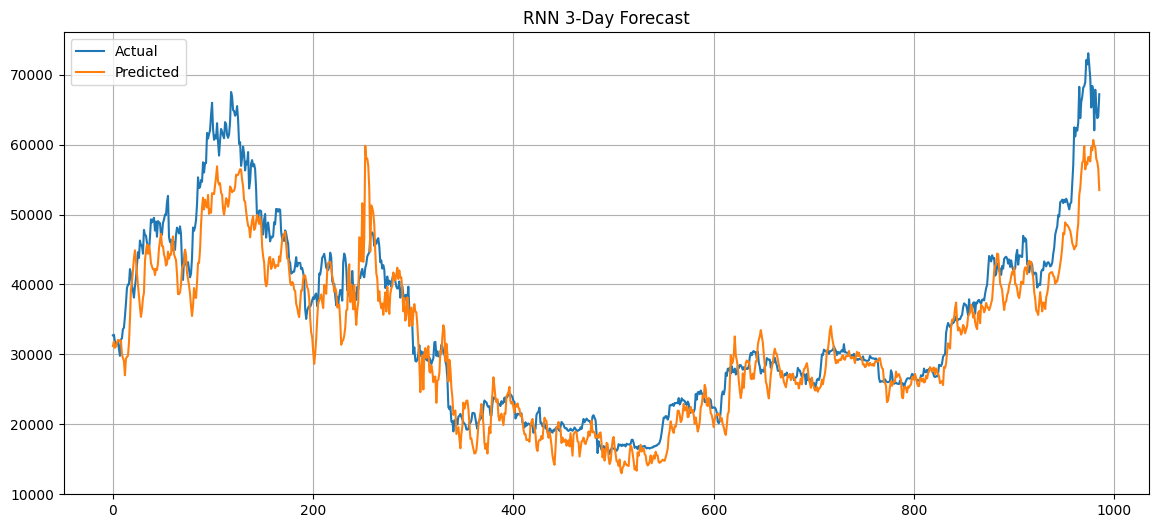

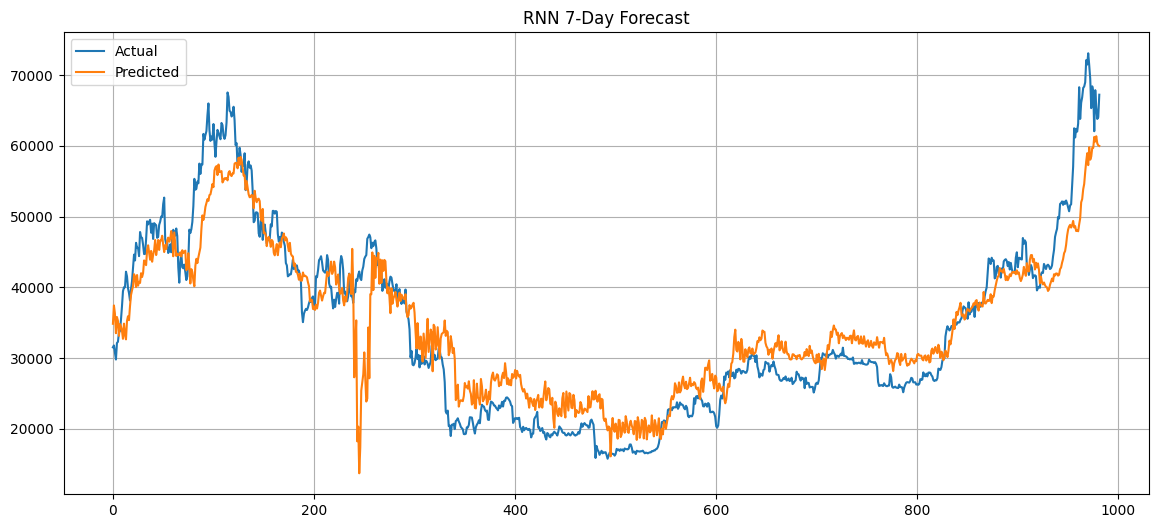

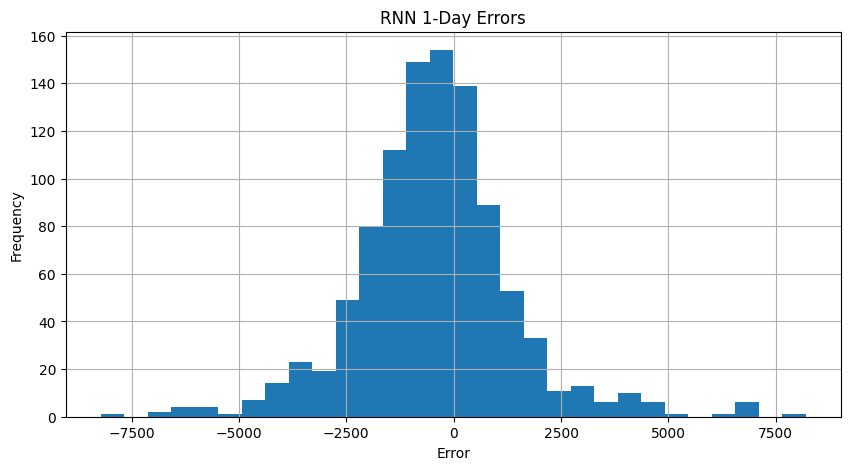

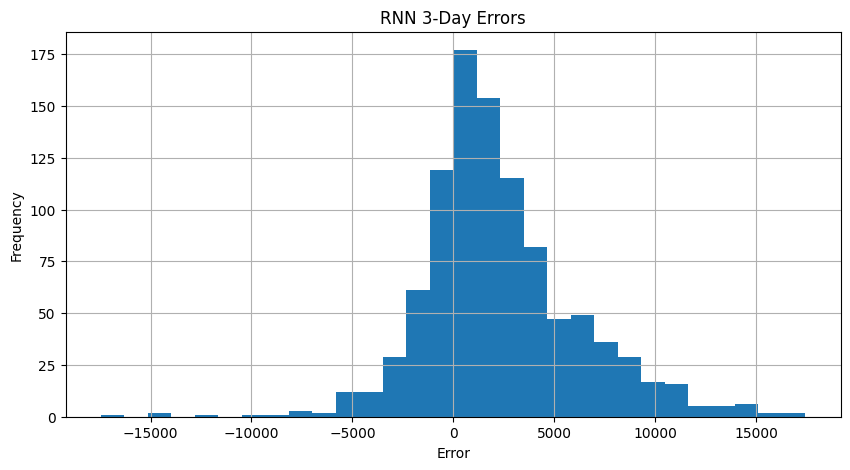

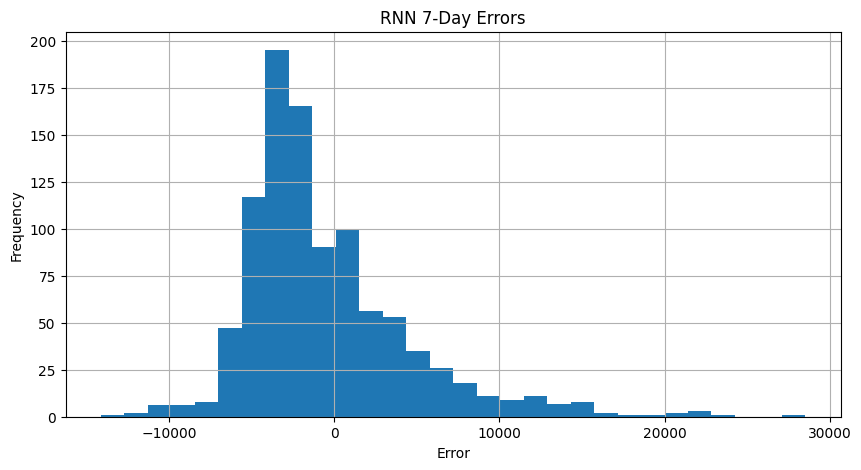

In [40]:
plot_forecast(y1_rnn, p1_rnn, "RNN 1-Day Forecast")
plot_forecast(y3_rnn, p3_rnn, "RNN 3-Day Forecast")
plot_forecast(y7_rnn, p7_rnn, "RNN 7-Day Forecast")

plot_error_distribution(y1_rnn, p1_rnn, "RNN 1-Day Errors")
plot_error_distribution(y3_rnn, p3_rnn, "RNN 3-Day Errors")
plot_error_distribution(y7_rnn, p7_rnn, "RNN 7-Day Errors")

TRANSFORMERS

In [41]:
#TRansformers
import tensorflow as tf
from tensorflow.keras.layers import (
    Dense, Dropout, LayerNormalization,
    MultiHeadAttention, GlobalAveragePooling1D, Input
)
from tensorflow.keras.models import Model

def transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.2):
    x = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x)

    res = x + inputs

    x = Dense(ff_dim, activation="relu")(res)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)

    return LayerNormalization(epsilon=1e-6)(x + res)

def build_transformer_model(input_shape):
    inputs = Input(shape=input_shape)

    x = transformer_encoder(inputs)
    x = GlobalAveragePooling1D()(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(0.2)(x)

    outputs = Dense(1)(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

transformer_1d = build_transformer_model(
    (X_train_1d.shape[1], X_train_1d.shape[2])
)

transformer_3d = build_transformer_model(
    (X_train_3d.shape[1], X_train_3d.shape[2])
)

transformer_7d = build_transformer_model(
    (X_train_7d.shape[1], X_train_7d.shape[2])
)

transformer_1d.fit(
    X_train_1d, y_train_1d,
    validation_data=(X_test_1d, y_test_1d),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

transformer_3d.fit(
    X_train_3d, y_train_3d,
    validation_data=(X_test_3d, y_test_3d),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

transformer_7d.fit(
    X_train_7d, y_train_7d,
    validation_data=(X_test_7d, y_test_7d),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

transformer_1d.save("transformer_1day.h5")
transformer_3d.save("transformer_3day.h5")
transformer_7d.save("transformer_7day.h5")

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 18s 70ms/step - loss: 0.0430 - mae: 0.1417 - val_loss: 0.0299 - val_mae: 0.1528
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0077 - mae: 0.0639 - val_loss: 0.0366 - val_mae: 0.1737
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0040 - mae: 0.0410 - val_loss: 0.0389 - val_mae: 0.1778
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0032 - mae: 0.0332 - val_loss: 0.0489 - val_mae: 0.2052
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0029 - mae: 0.0305 - val_loss: 0.0417 - val_mae: 0.1889
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0025 - mae: 0.0259 - val_loss: 0.1248 - val_mae: 0.3330
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0023 - mae: 0.0248 - val_loss: 0.0405 - val_mae: 0.1816
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0019 - mae: 0.0221 - val_loss: 0.0857 - val_mae: 0.2739
Epoch 9/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - 

In [42]:
y1_t, p1_t, mae1_t, rmse1_t, mape1_t, r21_t = evaluate_forecast(
    transformer_1d, X_test_1d, y_test_1d, target_scaler, "Transformer 1-Day"
)

y3_t, p3_t, mae3_t, rmse3_t, mape3_t, r23_t = evaluate_forecast(
    transformer_3d, X_test_3d, y_test_3d, target_scaler, "Transformer 3-Day"
)

y7_t, p7_t, mae7_t, rmse7_t, mape7_t, r27_t = evaluate_forecast(
    transformer_7d, X_test_7d, y_test_7d, target_scaler, "Transformer 7-Day"
)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step

Transformer 1-Day
MAE: 11162.51
RMSE: 12628.34
MAPE: 37.68%
R2: 0.0536
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

Transformer 3-Day
MAE: 19642.99
RMSE: 20917.66
MAPE: 67.49%
R2: -1.5914
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step

Transformer 7-Day
MAE: 5688.21
RMSE: 7107.94
MAPE: 18.56%
R2: 0.7020


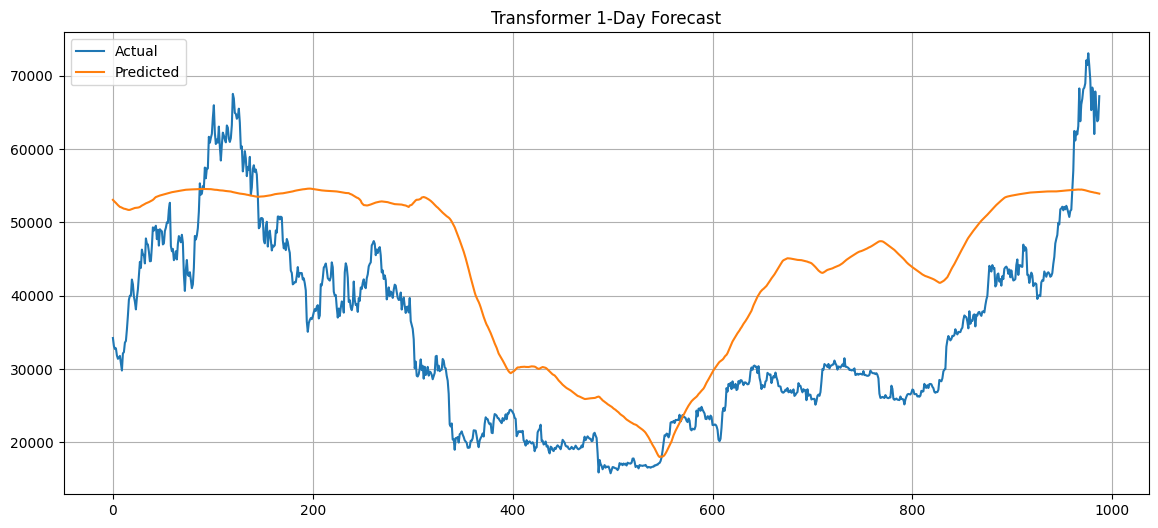

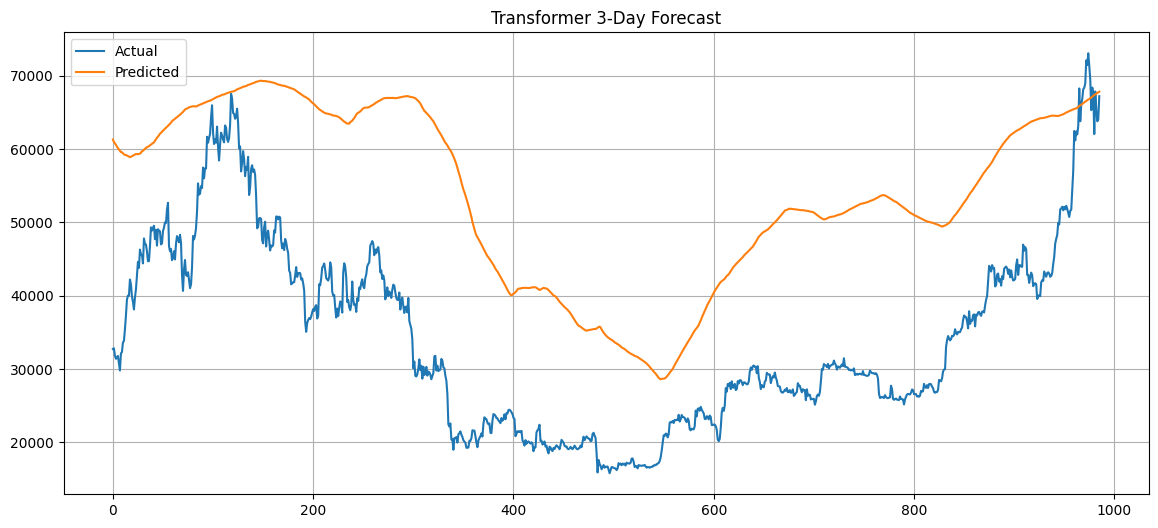

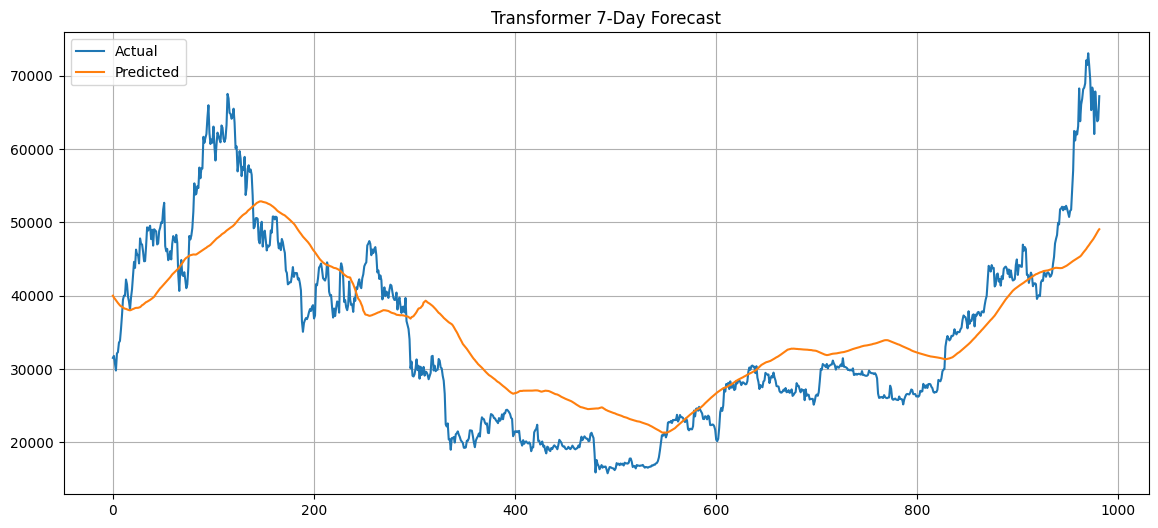

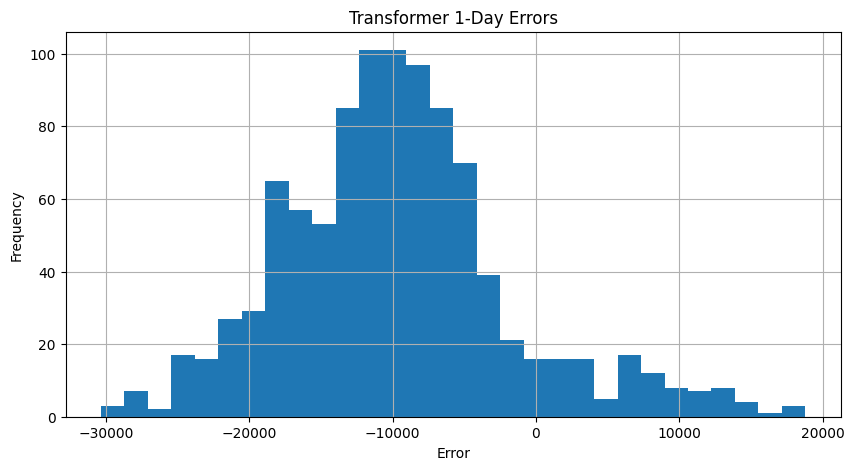

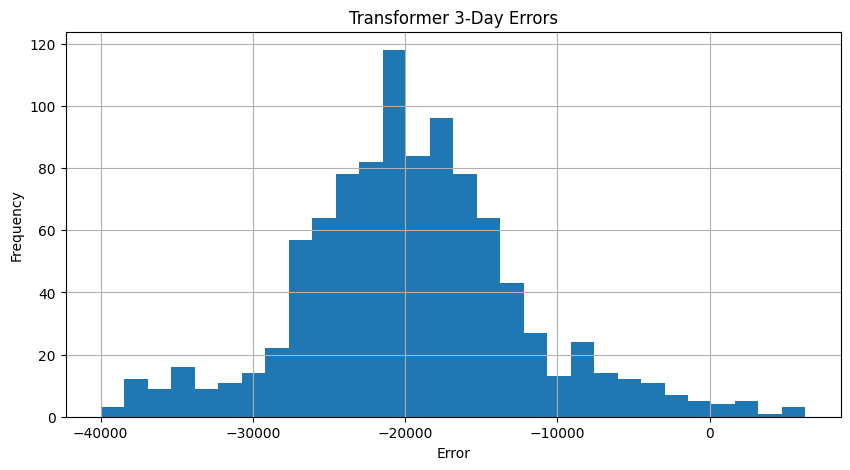

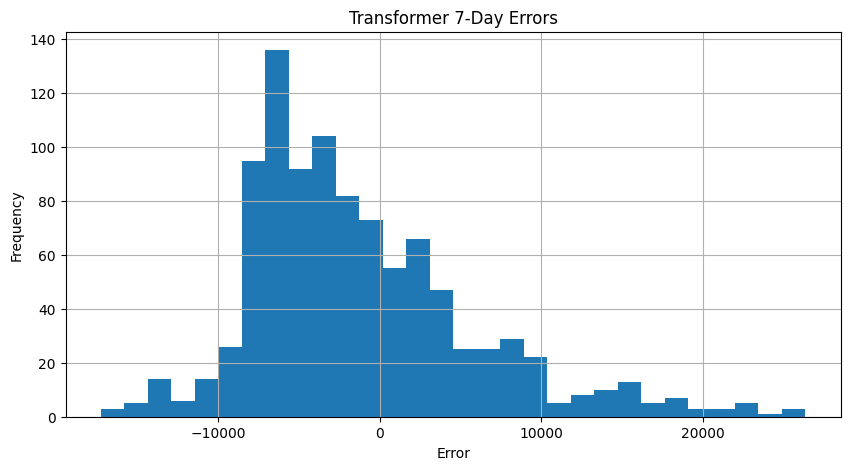

In [43]:
plot_forecast(y1_t, p1_t, "Transformer 1-Day Forecast")
plot_forecast(y3_t, p3_t, "Transformer 3-Day Forecast")
plot_forecast(y7_t, p7_t, "Transformer 7-Day Forecast")

plot_error_distribution(y1_t, p1_t, "Transformer 1-Day Errors")
plot_error_distribution(y3_t, p3_t, "Transformer 3-Day Errors")
plot_error_distribution(y7_t, p7_t, "Transformer 7-Day Errors")

In [44]:
#Final comparison
comparison_df = pd.DataFrame({
    "Model": ["CNN", "RNN", "LSTM", "Transformer"],
    "1D_R2": [r21, r21_rnn, r21, r21_t],
    "3D_R2": [r23, r23_rnn, r23, r23_t],
    "7D_R2": [r27, r27_rnn, r27, r27_t]
})

print(comparison_df)
comparison_df.to_csv("all_model_comparison.csv", index=False)

         Model     1D_R2     3D_R2     7D_R2
0          CNN  0.892281  0.878203  0.847154
1          RNN  0.978975  0.878631  0.847472
2         LSTM  0.892281  0.878203  0.847154
3  Transformer  0.053613 -1.591351  0.701962
